In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import tree
%matplotlib inline

In [2]:
Columns = ['age', 'workclass', 'fnlwgt', 'education',
           'education-num', 'marital-stauts', 'occupation',
           'relationship', 'race', 'sex', 'capital-gain',
           'capital-loss', 'hours-per-week', 'native-country',
           'income']

df = pd.read_csv('adult.data', names=Columns)

In [3]:
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-stauts,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


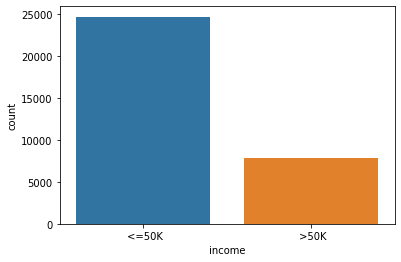

In [4]:
sns.countplot(df['income'])
plt.savefig('income.png',dpi=200)

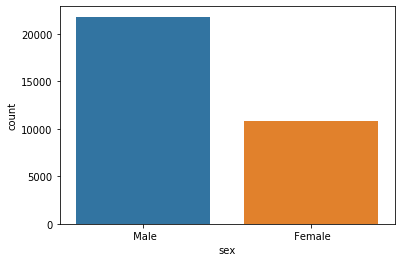

In [5]:
sns.countplot(df['sex'])

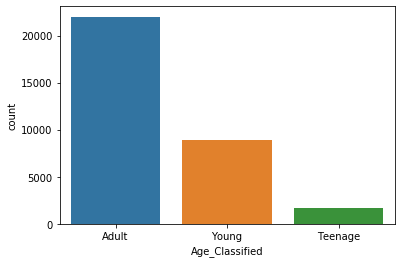

In [6]:
Classified_by_Age = pd.DataFrame()

def Classifie_Age(Age):
    Result = ''
    if Age<20: Result = 'Teenage'
    elif 20<=Age<=30: Result = 'Young'
    elif Age>30: Result = 'Adult'
    return Result

Classified_by_Age['Age_Classified'] = df['age'].apply(Classifie_Age)
sns.countplot(Classified_by_Age['Age_Classified'])

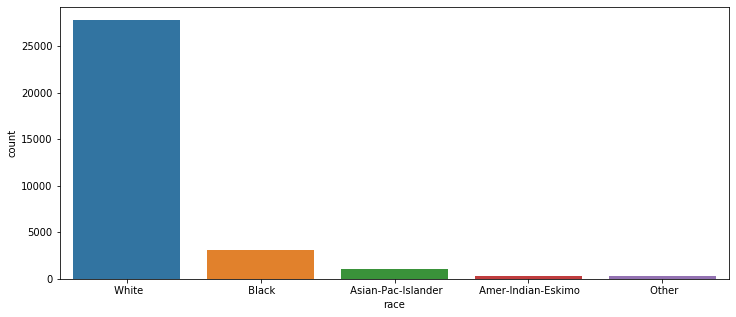

In [7]:
plt.figure(figsize=(12,5))
sns.countplot(df['race'])

## TO VIEW THIS PLOT PRESS RIGHT-CLICK ON IT AND SELECT VIEW IMAGE THEN ZOOM

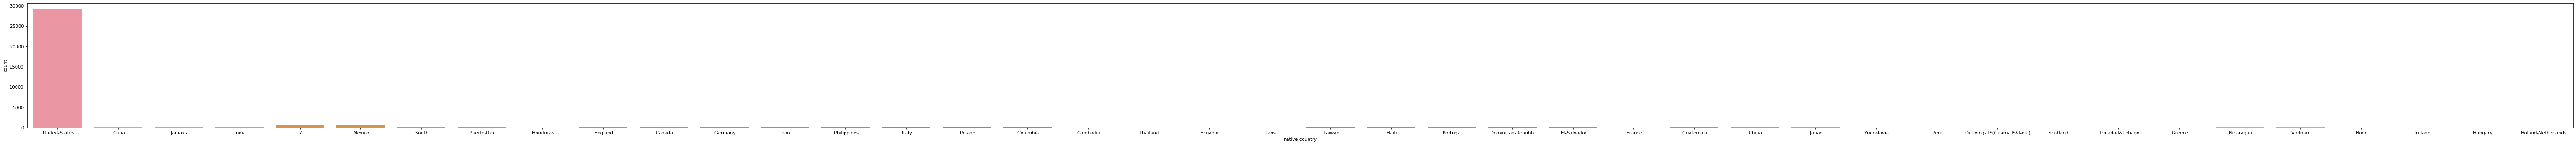

In [8]:
plt.figure(figsize=(100,5))
sns.countplot(df['native-country'])

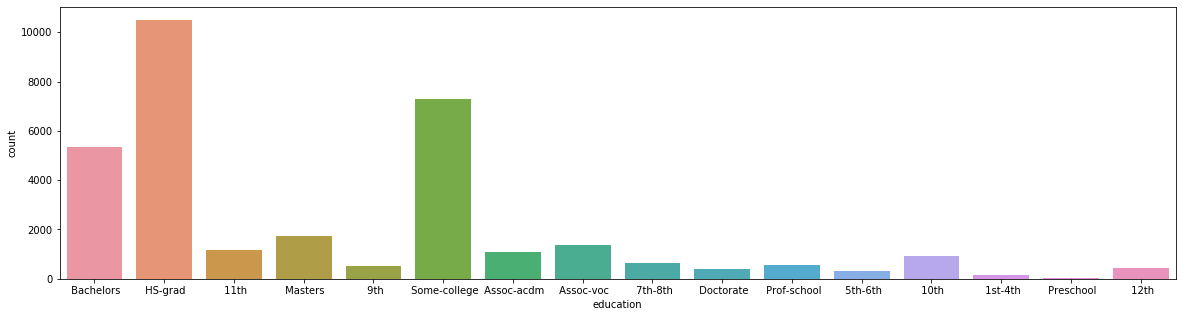

In [9]:
plt.figure(figsize=(20,5))
sns.countplot(df['education'])

In [10]:
df.drop(['workclass', 'fnlwgt', 'education',
       'marital-stauts', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss','native-country',
       ], inplace=True, axis=1)

In [11]:
df.columns

Index(['age', 'education-num', 'hours-per-week', 'income'], dtype='object')

In [12]:
df['income >50k'] = pd.get_dummies(df['income'], drop_first=True)

In [13]:
df.head(5)

,age,education-num,hours-per-week,income,income >50k
0,39,13,40,<=50K,0
1,50,13,13,<=50K,0
2,38,9,40,<=50K,0
3,53,7,40,<=50K,0
4,28,13,40,<=50K,0


In [14]:
df.drop('income',inplace=True, axis=1)

In [15]:
df.head(5)

,age,education-num,hours-per-week,income >50k
0,39,13,40,0
1,50,13,13,0
2,38,9,40,0
3,53,7,40,0
4,28,13,40,0


# NEAREST NEIGHBORS

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
...     df[['age','education-num','hours-per-week']],
    df['income >50k'], test_size=0.3, random_state=42)

In [17]:
KNN1 = KNeighborsClassifier(n_neighbors=1)

In [18]:
KNN1.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

In [19]:
predictions = KNN1.predict(X_test)

In [20]:
print(confusion_matrix(y_test, predictions))

[[6051 1404]
 [1311 1003]]


In [21]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      7455
           1       0.42      0.43      0.42      2314

    accuracy                           0.72      9769
   macro avg       0.62      0.62      0.62      9769
weighted avg       0.73      0.72      0.72      9769



## CHOOSING THE K VALUE

In [22]:
error_rate = []

for i in range(1,50):
    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(X_train, y_train)
    prediction = KNN.predict(X_test)
    error_rate.append(np.mean(prediction != y_test))

Text(0.5, 1.0, 'Choosing the K value')

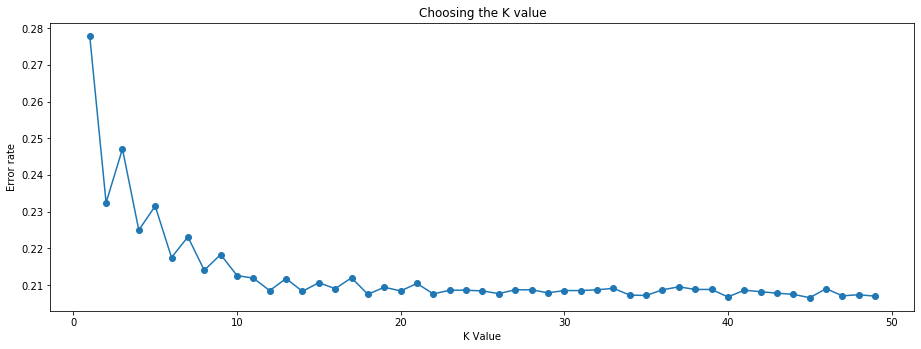

In [23]:
fig = plt.figure(figsize=(15,5))
ax = fig.add_axes([0.1,0.1,0.8,0.8])
ax.plot(range(1,50),error_rate, marker='o')
ax.set_xlabel('K Value')
ax.set_ylabel('Error rate')
ax.set_title('Choosing the K value')

In [24]:
print(error_rate.index(min(error_rate)) + 1, min(error_rate))

45 0.20657180878288464


In [25]:
KNN2 = KNeighborsClassifier(n_neighbors=45)
KNN2.fit(X_train, y_train)
predictions2 = KNN2.predict(X_test)

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[6051 1404]
 [1311 1003]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      7455
           1       0.42      0.43      0.42      2314

    accuracy                           0.72      9769
   macro avg       0.62      0.62      0.62      9769
weighted avg       0.73      0.72      0.72      9769



In [61]:
Columns = ['age', 'workclass', 'fnlwgt', 'education',
           'education-num', 'marital-stauts', 'occupation',
           'relationship', 'race', 'sex', 'capital-gain',
           'capital-loss', 'hours-per-week', 'native-country',
           'income']

adults = pd.read_csv('adult.data', names=Columns)
adults['income'] = pd.get_dummies(adults['income'])
adults['sex'] = pd.get_dummies(adults['sex'])
adults.drop(['workclass','education','marital-stauts', 'relationship', 'occupation', 'native-country'],
           axis = 1, inplace = True)
adults['race'] = pd.get_dummies(adults['race'])[' White']

In [64]:

X_train, X_test, y_train, y_test = train_test_split(
...     adults[['age', 'fnlwgt', 'education-num', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week']],
    adults['income'], test_size=0.3, random_state=42)

In [65]:
TreeModel = tree.DecisionTreeClassifier()
TreeModel.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [66]:
predictions = TreeModel.predict(X_test)

In [67]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[1254 1060]
 [1138 6317]]
              precision    recall  f1-score   support

           0       0.52      0.54      0.53      2314
           1       0.86      0.85      0.85      7455

    accuracy                           0.78      9769
   macro avg       0.69      0.69      0.69      9769
weighted avg       0.78      0.78      0.78      9769

